# Carrier Agent Cockpit: metrics pipeline

Every number on the cockpit is **computed with SQL from event-level data**, not typed in.

`generate.py` produces a deterministic synthetic brokerage:

- 40,000 outbound agent touches across three carrier segments
- 2,980 bookings
- 2,400 carriers in weekly cohorts
- a 250-call QA sample

This notebook loads it into **SQLite** and builds the metric tree. The tests assert that each figure matches the React dashboard.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import metrics

con = metrics.connect()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.read_sql_query("""SELECT 'touches' AS tbl, COUNT(*) AS rows FROM touches UNION ALL
                     SELECT 'bookings', COUNT(*) FROM bookings UNION ALL
                     SELECT 'carriers', COUNT(*) FROM carriers UNION ALL
                     SELECT 'call_reviews', COUNT(*) FROM call_reviews""", con)

,tbl,rows
0,touches,40000
1,bookings,2980
2,carriers,2400
3,call_reviews,250


## 1. Coverage funnel by segment (per 1,000 touches)

,touches,connected_per_1k,qualified_per_1k,quoted_per_1k,booked_per_1k
segment,,,,,
all,40000,412.0,268.0,190.0,75.0
oo,16000,468.0,274.0,205.0,81.0
sf,16400,401.0,281.0,196.0,79.0
mf,7600,318.0,226.0,148.0,51.0


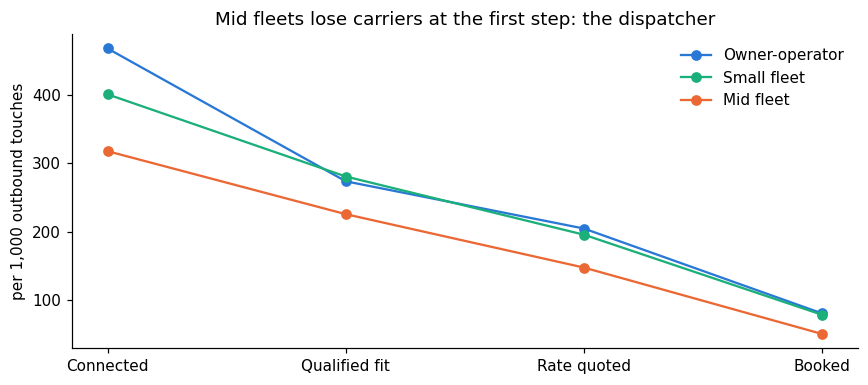

In [2]:
f = metrics.run(con, "01").set_index("segment")
stages = ["connected_per_1k", "qualified_per_1k", "quoted_per_1k", "booked_per_1k"]
ax = f.loc[["oo", "sf", "mf"], stages].T.plot(marker="o", figsize=(8, 3.6), color=["#2a78d6", "#1baf7a", "#eb6834"])
ax.set_xticks(range(4)); ax.set_xticklabels(["Connected", "Qualified fit", "Rate quoted", "Booked"])
ax.set_ylabel("per 1,000 outbound touches"); ax.legend(["Owner-operator", "Small fleet", "Mid fleet"], frameon=False)
ax.set_title("Mid fleets lose carriers at the first step: the dispatcher")
plt.tight_layout(); plt.savefig("figures/funnel_by_segment.png")
f

## 2. Where each segment breaks first

In [3]:
metrics.run(con, "02")

,segment,worst_stage,drop_pct
0,Mid fleet (31+),Connected,68.0
1,Owner-operator (1-5),Booked,60.0
2,Small fleet (6-30),Connected,60.0


## 3. Autonomy vs. escalation, week by week

,week,pct_booked_no_human,pct_escalated
0,1,48.7,19.5
1,2,49.4,19.1
2,3,51.2,18.4
3,4,50.0,18.8
4,5,53.2,17.2
5,6,54.9,16.4
6,7,54.7,16.9
7,8,57.3,15.1
8,9,58.6,14.4
9,10,60.2,13.8


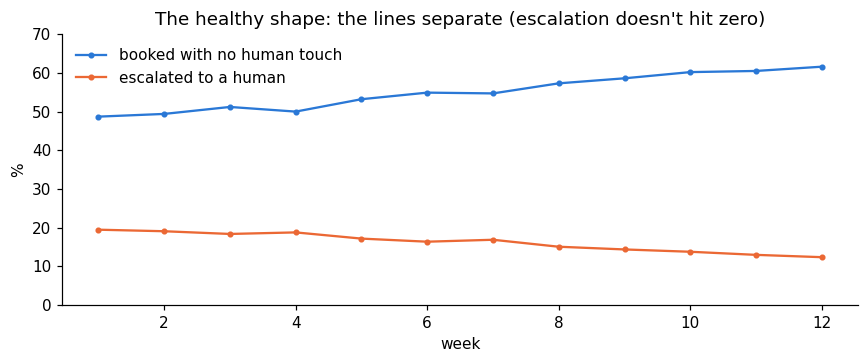

In [4]:
t = metrics.run(con, "03")
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(t.week, t.pct_booked_no_human, color="#2a78d6", marker="o", ms=3, label="booked with no human touch")
ax.plot(t.week, t.pct_escalated, color="#eb6834", marker="o", ms=3, label="escalated to a human")
ax.set_ylim(0, 70); ax.set_xlabel("week"); ax.set_ylabel("%"); ax.legend(frameon=False)
ax.set_title("The healthy shape: the lines separate (escalation doesn't hit zero)")
plt.tight_layout(); fig.savefig("figures/autonomy_vs_escalation.png")
t

## 4. Segment scorecard
The median and p90 time-to-cover are computed in SQL with `ROW_NUMBER()` windows. SQLite has no percentile function.

In [5]:
metrics.run(con, "04")

,segment,pct_no_human_w12,median_min_to_cover,p90_min_to_cover,d30_repeat_pct,rate_delta_pct
0,all,62.0,35.0,159.0,34.0,1.5
1,oo,67.0,31.0,129.0,41.0,0.9
2,sf,60.0,36.0,164.0,33.0,1.6
3,mf,48.0,54.0,253.0,22.0,3.1


## 5. Do carriers come back?

In [6]:
metrics.run(con, "05")

,cohort,carriers,d30_repeat_pct,owner_op_pct,mid_fleet_pct
0,W1,400,29.0,29.0,29.0
1,W2,400,31.0,31.0,32.0
2,W3,400,30.0,30.0,30.0
3,W4,400,35.0,35.0,36.0
4,W5,400,37.0,37.0,37.0
5,W6,400,34.0,41.0,22.0


## 6. Where conversations break, and who owns the fix

,failure_mode,calls,pct_of_sample,cost,owner,load_value_at_risk_usd
0,Special instruction dropped,68,27.2,Fall-off / TONU,Product,216961.0
1,Anchored high on a soft lane,54,21.6,Margin,Pricing,175122.0
2,Equipment mismatch surfaced late,41,16.4,Wasted call,Matching,140730.0
3,Carrier abandoned during vetting,39,15.6,Lost supply,Trust & safety,120443.0
4,"Agent looped, carrier hung up",27,10.8,Carrier trust,Product,89496.0
5,"Escalated, no human available",21,8.4,Coverage delay,Ops,74004.0


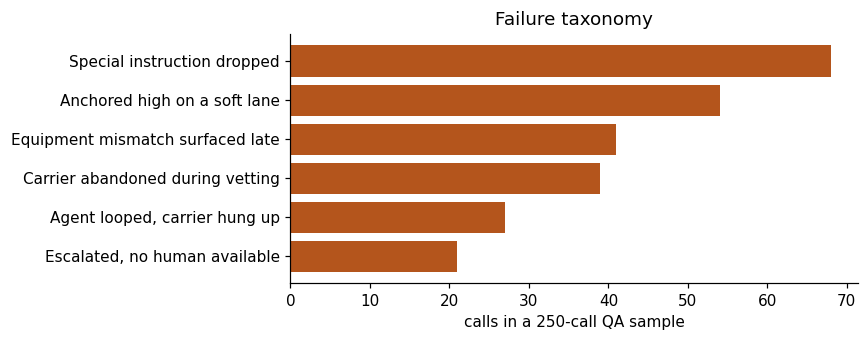

In [7]:
fail = metrics.run(con, "06")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(fail.failure_mode[::-1], fail.calls[::-1], color="#b4551c")
ax.set_xlabel("calls in a 250-call QA sample"); ax.set_title("Failure taxonomy")
plt.tight_layout(); fig.savefig("figures/failure_taxonomy.png")
fail

In [8]:
metrics.run(con, "07")

,owner,calls,failure_modes,load_value_at_risk_usd
0,Product,95,"Special instruction dropped,Agent looped, carr...",306457.0
1,Pricing,54,Anchored high on a soft lane,175122.0
2,Matching,41,Equipment mismatch surfaced late,140730.0
3,Trust & safety,39,Carrier abandoned during vetting,120443.0
4,Ops,21,"Escalated, no human available",74004.0


## Takeaways

1. **Owner-operators and mid fleets are different products.** Mid fleets lose 68% of touches at *connect*, because a dispatcher answers instead of the driver. That's a workflow problem, not a conversation-quality problem.
2. **Autonomy is rising while escalation falls,** and escalation is leveling off rather than heading to zero. That's the healthy pattern.
3. **Mid-fleet carriers aren't coming back:** a 22% repeat rate vs. 41% for owner-operators, and they cost 3.1% over target buy.
4. **Product owns the largest share of sampled failures,** and dropped special instructions lead the list. That's the first backlog item.